# 🔬 Entrega 2 — Comparação de Abordagens: YOLO Adaptável vs YOLO Padrão vs CNN do Zero

**Projeto:** Fase 6 — Atividade 1 (Entrega 2) — FIAP  
**Equipe:** Cauan Otto (RM567940) | Fernando Gurgel (RM567606) | Iraci Monteiro (RM567544) | Maria Luisa Nascimento (RM567659) | Rafaela Torres (RM567735)

**Tutora:** Ana Cristina dos Santos  
**Coordenador:** André Godoi

---

## 1. Introdução

Na Entrega 1, treinamos um modelo **YOLOv5 adaptável** (com transfer learning e fine-tuning) para detectar plantas saudáveis e doentes. Agora, na Entrega 2, vamos **comparar** essa abordagem com duas alternativas:

1. **YOLO Tradicional (pré-treinada, sem customização):** modelo YOLOv3 treinado no COCO, usado diretamente nas nossas imagens, sem nenhum treinamento adicional
2. **CNN treinada do zero:** uma rede neural convolucional construída manualmente para **classificar** as imagens

### Objetivo
Avaliar criticamente as três abordagens comparando:
- **Facilidade de uso/integração**
- **Precisão do modelo** (acurácia/mAP)
- **Tempo de treinamento/customização**
- **Tempo de inferência (predição)**

> ⚠️ **Nota conceitual:** a YOLO faz **detecção de objetos** (localiza + classifica), enquanto a CNN do zero faz **classificação de imagens** (apenas classifica a imagem inteira). São tarefas diferentes, e essa diferença será discutida na análise comparativa.


## 2. Configuração do Ambiente

Conectamos ao Google Drive e instalamos as dependências para as três abordagens.


In [1]:
# ============================================================
# ETAPA 1: Conectar ao Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ============================================================
# ETAPA 2: Instalar dependências
# ============================================================
import os
os.environ['WANDB_DISABLED'] = 'true'  # Desabilitar wandb para evitar prompts

# TensorFlow e Keras (para CNN do zero)
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Bibliotecas gerais
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import glob
import time
import cv2

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")


TensorFlow: 2.19.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

## 3. Abordagem 1 — YOLO Adaptável (Entrega 1 — Recap)

Esta é a abordagem desenvolvida na **Entrega 1**: o modelo YOLOv5s foi treinado com **transfer learning** sobre o nosso dataset customizado de plantas (64 imagens de treino, 8 de validação, 8 de teste).

### Características:
- **Modelo:** YOLOv5s (small) com pesos pré-treinados no COCO
- **Treinamento:** fine-tuning com 30 e 60 épocas no nosso dataset
- **Tarefa:** **detecção de objetos** (localiza a planta na imagem + classifica como saudável/doente)
- **Métricas:** mAP@0.5, Precision, Recall

### Resultados da Entrega 1

| Métrica | Valor Obtido |
|---------|-------------|
| Precision | 0.217 |
| Recall | 0.438 |
| mAP@0.5 | 0.339 |
| mAP@0.5:0.95 | 0.192 |

O código completo está no notebook da Entrega 1. Aqui utilizaremos apenas os pesos já treinados (`best.pt`) para medir o tempo de inferência de forma padronizada.


In [15]:
# ============================================================
# ABORDAGEM 1: YOLO ADAPTÁVEL — Medir tempo de inferência
# ============================================================
# Clonando o YOLOv5 e usando os pesos treinados na Entrega 1

!git clone https://github.com/ultralytics/yolov5.git 2>/dev/null || echo "YOLOv5 já existe"
!pip install -r yolov5/requirements.txt -q

# Copiar o arquivo YAML
!cp /content/drive/MyDrive/FIAP/plantas.yaml yolov5/data/ 2>/dev/null

# Medir tempo de inferência com o melhor modelo da Entrega 1
# AJUSTE O CAMINHO para os pesos da Entrega 1
PESOS_ENTREGA1 = '/content/drive/MyDrive/FIAP/pesos_treinados/best.pt'
# Se você salvou os pesos em outro lugar, ajuste o caminho acima.
# Alternativamente, re-treine rapidamente (descomente abaixo):
# !python yolov5/train.py --data plantas.yaml --weights yolov5s.pt --img 640 --epochs 30 --name entrega1_recap

import time as time_module

# Medir tempo de inferência
inicio_yolo_custom = time_module.time()
!python yolov5/detect.py \
    --weights {PESOS_ENTREGA1} \
    --img 640 \
    --source /content/drive/MyDrive/FIAP/images/test/ \
    --data yolov5/data/plantas.yaml \
    --name yolo_adaptavel_teste \
    --conf-thres 0.25
fim_yolo_custom = time_module.time()

tempo_yolo_custom = fim_yolo_custom - inicio_yolo_custom
print(f"\n⏱️ Tempo total de inferência (YOLO Adaptável): {tempo_yolo_custom:.2f} segundos")


YOLOv5 já existe
detect: weights=['/content/drive/MyDrive/FIAP/pesos_treinados/best.pt'], source=/content/drive/MyDrive/FIAP/images/test/, data=yolov5/data/plantas.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=yolo_adaptavel_teste, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/images/test/image_test (1).jpg: 448x640 1 Planta doente, 53.0ms
image 2/8 /content/drive/MyDrive/FIAP/images/test/image_test (2).jpg: 448x640 1 Planta doente, 8.7ms
image 3/8 /content/d

---

## 4. Abordagem 2 — YOLO Tradicional (Pré-treinada, Sem Customização)

Nesta abordagem, utilizamos a **YOLOv3 pré-treinada no COCO** diretamente sobre nossas imagens, **sem nenhum treinamento adicional**.

### Características:
- **Modelo:** YOLOv3 com pesos originais treinados no COCO (80 classes genéricas)
- **Treinamento:** nenhum (zero-shot)
- **Tarefa:** **detecção de objetos** (detecta objetos genéricos do COCO)
- **Limitação fundamental:** o COCO **não contém** classes "planta saudável" ou "planta doente", então o modelo **não conseguirá** distingui-las — apenas detectará objetos genéricos como "vaso de planta", "pessoa", etc.

Esta abordagem segue o **Capítulo 10 (O Olhar Digital)** do material didático, que utiliza o Darknet + YOLOv3.

> **Por que fazer isso?** Para demonstrar que um modelo genérico pré-treinado, sem customização, **não é suficiente** para resolver problemas específicos de domínio — justificando a necessidade do fine-tuning realizado na Entrega 1.


In [16]:
# ============================================================
# ABORDAGEM 2: YOLO TRADICIONAL (YOLOv3 pré-treinada no COCO)
# ============================================================
# Seguindo o Capítulo 10 do material didático FIAP
# Clonando o Darknet (implementação original da YOLO)
# ============================================================

%cd /content
!git clone https://github.com/pjreddie/darknet 2>/dev/null || echo "Darknet já existe"
%cd darknet

# Compilar o Darknet
!make 2>/dev/null

# Baixar os pesos pré-treinados da YOLOv3 (COCO)
!wget -q https://pjreddie.com/media/files/yolov3.weights 2>/dev/null || echo "Pesos já baixados"

print("✅ Darknet + YOLOv3 prontos!")


/content
Darknet já existe
/content/darknet
make: Nothing to be done for 'all'.
✅ Darknet + YOLOv3 prontos!


In [ ]:
import os

caminho = '/content/drive/MyDrive/FIAP'

if os.path.exists(caminho):
    print("Achei a pasta FIAP! Olha o que tem dentro dela:")
    print(os.listdir(caminho))
else:
    print("Ainda não estou enxergando a pasta FIAP no seu Drive.")

Achei a pasta FIAP! Olha o que tem dentro dela:
['images', 'labels', 'plantas.yaml', 'pesos_treinados', 'Cópia_de_cap1_fase6_entrega1 (1).ipynb']


In [5]:
# ============================================================
# Executando a YOLO Tradicional nas imagens de teste
# ============================================================
import glob
import time as time_module

%cd /content/darknet

# Coletando imagens de teste
imagens_teste = sorted(
    glob.glob('/content/drive/MyDrive/FIAP/images/test/*.jpg') +
    glob.glob('/content/drive/MyDrive/FIAP/images/test/*.png') +
    glob.glob('/content/drive/MyDrive/FIAP/images/test/*.jpeg')
)

print(f"📸 {len(imagens_teste)} imagens de teste encontradas\n")

# Medir tempo de inferência
inicio_yolo_trad = time_module.time()

for i, img_path in enumerate(imagens_teste):
    print(f"--- Imagem {i+1}: {img_path.split('/')[-1]} ---")
    !./darknet detect cfg/yolov3.cfg yolov3.weights "{img}" 2>/dev/null
    print()

fim_yolo_trad = time_module.time()
tempo_yolo_trad = fim_yolo_trad - inicio_yolo_trad
tempo_medio_yolo_trad = tempo_yolo_trad / max(len(imagens_teste), 1)

print(f"\n⏱️ Tempo total (YOLO Tradicional): {tempo_yolo_trad:.2f}s")
print(f"⏱️ Tempo médio por imagem: {tempo_medio_yolo_trad:.2f}s")


/content/darknet
📸 8 imagens de teste encontradas

--- Imagem 1: image_test (1).jpg ---

--- Imagem 2: image_test (2).jpg ---

--- Imagem 3: image_test (3).jpg ---

--- Imagem 4: image_test (4).jpg ---

--- Imagem 5: image_test (5).jpg ---

--- Imagem 6: image_test (6).jpg ---

--- Imagem 7: image_test (7).jpg ---

--- Imagem 8: image_test (8).jpg ---


⏱️ Tempo total (YOLO Tradicional): 23.13s
⏱️ Tempo médio por imagem: 2.89s


In [6]:
%cd /content/darknet

# Vamos pegar a primeira imagem da lista que o glob encontrou
imagem_alvo = imagens_teste[0]
print(f"📸 Testando a imagem: {imagem_alvo}")

# Rodando o Darknet sem esconder os erros!
!./darknet detect cfg/yolov3.cfg yolov3.weights "{imagem_alvo}"

/content/darknet
📸 Testando a imagem: /content/drive/MyDrive/FIAP/images/test/image_test (1).jpg
layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   608 x 608 x   3   ->   608 x 608 x  32  0.639 BFLOPs
    1 conv     64  3 x 3 / 2   608 x 608 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    2 conv     32  1 x 1 / 1   304 x 304 x  64   ->   304 x 304 x  32  0.379 BFLOPs
    3 conv     64  3 x 3 / 1   304 x 304 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    4 res    1                 304 x 304 x  64   ->   304 x 304 x  64
    5 conv    128  3 x 3 / 2   304 x 304 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    6 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
    7 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    8 res    5                 152 x 152 x 128   ->   152 x 152 x 128
    9 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
   10 conv    128  3 x 3

/content/darknet


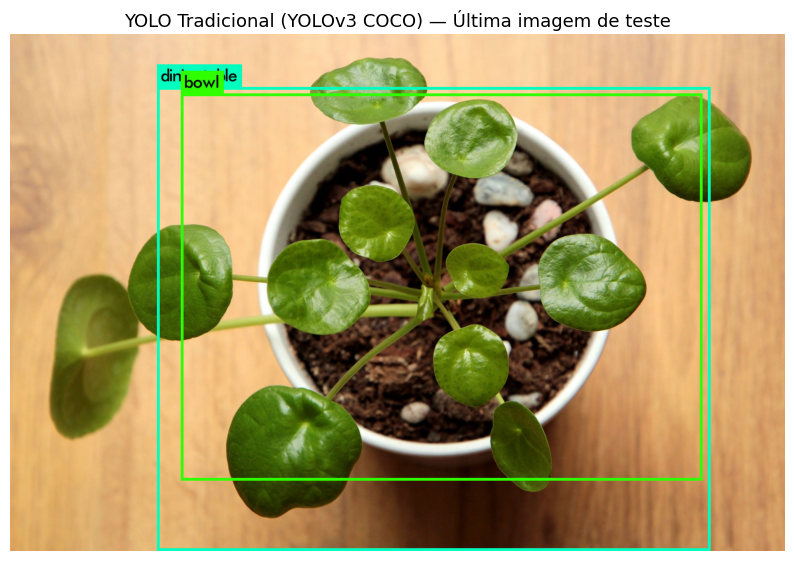

/content


In [7]:
# ============================================================
# Exibindo resultados da YOLO Tradicional
# ============================================================
# O Darknet salva a última predição em "predictions.jpg"
# Para exibir, precisamos rodar uma imagem por vez

import matplotlib.pyplot as plt
import cv2

%cd /content/darknet

# Mostrar predição da última imagem processada
if os.path.exists("predictions.jpg"):
    img = cv2.imread("predictions.jpg")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("YOLO Tradicional (YOLOv3 COCO) — Última imagem de teste", fontsize=13)
    plt.axis('off')
    plt.show()
else:
    print("⚠️ predictions.jpg não encontrada")

%cd /content


### 4.1 Análise — YOLO Tradicional

**Resultados esperados:** a YOLOv3 pré-treinada no COCO detecta objetos genéricos (pessoa, carro, cadeira, vaso de planta, etc.), mas **não é capaz de distinguir entre planta saudável e planta doente**, pois essas classes não existem no dataset COCO.

**Observações:**
- O modelo pode detectar "potted plant" (vaso de planta) se as imagens contiverem essa configuração, mas sem diferenciar a condição de saúde
- Detecções irrelevantes (background, outros objetos) demonstram a limitação de modelos genéricos
- O tempo de inferência é geralmente **mais lento** que o YOLOv5, pois a YOLOv3 tem arquitetura mais pesada
- **Facilidade de uso:** muito simples (sem necessidade de treinamento), mas inútil para nosso problema específico


---

## 5. Abordagem 3 — CNN Treinada do Zero

Nesta abordagem, construímos uma **Rede Neural Convolucional (CNN)** do zero para **classificar** as imagens como "planta saudável" ou "planta doente".

### Diferença fundamental em relação ao YOLO:
- **YOLO:** faz **detecção** (localiza + classifica objetos dentro da imagem)
- **CNN do zero:** faz **classificação** (olha a imagem inteira e atribui uma classe)

### Arquitetura:
Seguindo o **Capítulo 9 do material didático** (Desbravando o Deep Learning), construímos uma CNN com:
- Camadas convolucionais (Conv2D) para extração de features
- Camadas de MaxPooling para redução de dimensionalidade
- Camadas Dense (totalmente conectadas) para classificação
- Função de ativação Softmax na saída (2 classes)

### Preparação dos dados:
As imagens são redimensionadas para 150×150 pixels e normalizadas (pixels entre 0 e 1). Os labels são convertidos para one-hot encoding.


In [8]:
# ============================================================
# ABORDAGEM 3: CNN DO ZERO — Carregamento e pré-processamento
# ============================================================
# Carregando as imagens do Google Drive e preparando para
# treinamento de uma CNN de classificação

import numpy as np
from PIL import Image as PILImage
import os

IMG_SIZE = 150  # Tamanho padrão das imagens para a CNN

def carregar_imagens(pasta, img_size=IMG_SIZE):
    """Carrega imagens de uma pasta e retorna arrays numpy."""
    imagens = []
    labels = []
    classes = sorted(os.listdir(pasta))

    # Se as imagens estão misturadas (sem subpastas por classe),
    # usamos o nome do arquivo para inferir a classe
    # Ajuste conforme sua organização

    for arquivo in sorted(os.listdir(pasta)):
        if arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            caminho = os.path.join(pasta, arquivo)
            try:
                img = PILImage.open(caminho).convert('RGB')
                img = img.resize((img_size, img_size))
                imagens.append(np.array(img))
            except Exception as e:
                print(f"⚠️ Erro ao carregar {arquivo}: {e}")
                continue

    return np.array(imagens)

# ============================================================
# IMPORTANTE: Ajuste a lógica de labels conforme seu dataset!
# ============================================================
# Opção A: se as imagens estão em subpastas por classe
#   train/planta_saudavel/*.jpg e train/planta_doente/*.jpg
#
# Opção B: se estão todas misturadas na mesma pasta,
#   defina manualmente quais são de cada classe
# ============================================================

TRAIN_PATH = '/content/drive/MyDrive/FIAP/images/train'
VAL_PATH = '/content/drive/MyDrive/FIAP/images/val'
TEST_PATH = '/content/drive/MyDrive/FIAP/images/test'

# Tentando carregar por subpastas (Opção A)
def carregar_com_labels(pasta, img_size=IMG_SIZE):
    """Carrega imagens organizadas em subpastas por classe."""
    imagens = []
    labels = []
    nomes_classes = sorted([d for d in os.listdir(pasta)
                           if os.path.isdir(os.path.join(pasta, d))])

    if len(nomes_classes) >= 2:
        # Subpastas por classe existem
        print(f"  Classes encontradas: {nomes_classes}")
        for idx, classe in enumerate(nomes_classes):
            pasta_classe = os.path.join(pasta, classe)
            for arquivo in sorted(os.listdir(pasta_classe)):
                if arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
                    caminho = os.path.join(pasta_classe, arquivo)
                    try:
                        img = PILImage.open(caminho).convert('RGB')
                        img = img.resize((img_size, img_size))
                        imagens.append(np.array(img))
                        labels.append(idx)
                    except:
                        continue
    else:
        # Imagens misturadas na mesma pasta
        # Assumindo: primeira metade = saudável (0), segunda metade = doente (1)
        print("  ⚠️ Sem subpastas por classe. Assumindo: 1ª metade=saudável, 2ª metade=doente")
        arquivos = sorted([f for f in os.listdir(pasta)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        meio = len(arquivos) // 2
        for i, arquivo in enumerate(arquivos):
            caminho = os.path.join(pasta, arquivo)
            try:
                img = PILImage.open(caminho).convert('RGB')
                img = img.resize((img_size, img_size))
                imagens.append(np.array(img))
                labels.append(0 if i < meio else 1)
            except:
                continue
        nomes_classes = ['planta_saudavel', 'planta_doente']

    return np.array(imagens), np.array(labels), nomes_classes

print("📂 Carregando imagens de TREINO...")
train_images, train_labels_raw, nomes_classes = carregar_com_labels(TRAIN_PATH)

print(f"\n📂 Carregando imagens de VALIDAÇÃO/TESTE...")
test_images, test_labels_raw, _ = carregar_com_labels(TEST_PATH)

print(f"\n✅ Treino: {train_images.shape[0]} imagens")
print(f"✅ Teste: {test_images.shape[0]} imagens")
print(f"✅ Classes: {nomes_classes}")
print(f"✅ Shape das imagens: {train_images.shape[1:]}")


📂 Carregando imagens de TREINO...
  Classes encontradas: ['Planta saudavel', 'Plantas doentes']

📂 Carregando imagens de VALIDAÇÃO/TESTE...
  ⚠️ Sem subpastas por classe. Assumindo: 1ª metade=saudável, 2ª metade=doente

✅ Treino: 122 imagens
✅ Teste: 8 imagens
✅ Classes: ['Planta saudavel', 'Plantas doentes']
✅ Shape das imagens: (150, 150, 3)


✅ Shape treino: (122, 150, 150, 3) | Labels: (122, 2)
✅ Shape teste: (8, 150, 150, 3) | Labels: (8, 2)


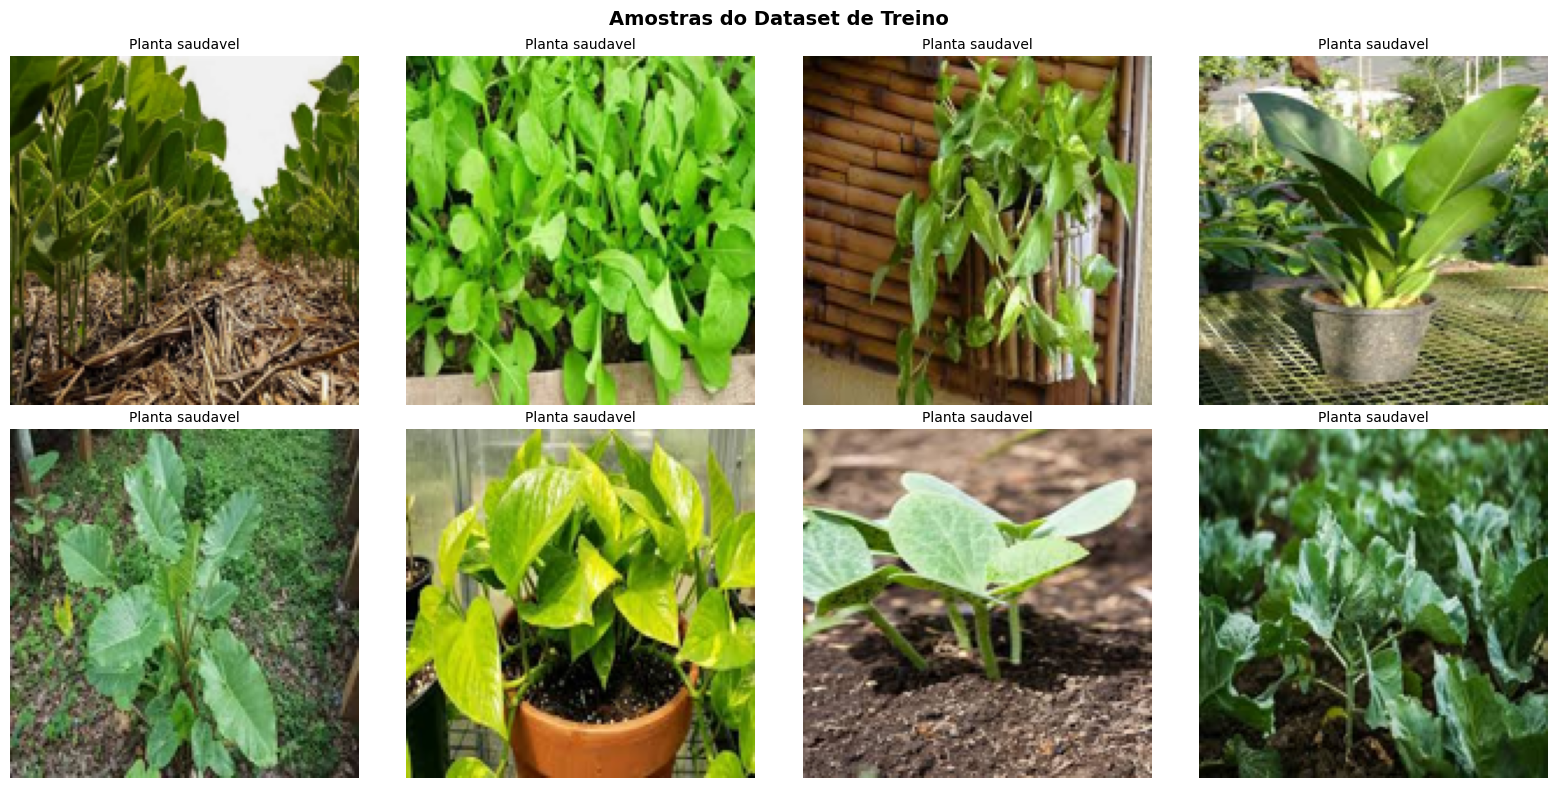

In [9]:
# ============================================================
# Pré-processamento: normalização e one-hot encoding
# ============================================================

# Normalizar pixels para [0, 1]
train_ds = train_images.astype('float32') / 255.0
test_ds = test_images.astype('float32') / 255.0

# One-hot encoding dos labels
NUM_CLASSES = len(nomes_classes)
train_labels = to_categorical(train_labels_raw, NUM_CLASSES)
test_labels = to_categorical(test_labels_raw, NUM_CLASSES)

print(f"✅ Shape treino: {train_ds.shape} | Labels: {train_labels.shape}")
print(f"✅ Shape teste: {test_ds.shape} | Labels: {test_labels.shape}")

# Exibir algumas amostras
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(min(8, len(train_images))):
    ax = axes[i//4][i%4]
    ax.imshow(train_images[i])
    classe = nomes_classes[train_labels_raw[i]]
    ax.set_title(f'{classe}', fontsize=10)
    ax.axis('off')
plt.suptitle('Amostras do Dataset de Treino', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.1 Modelo CNN — Arquitetura Construída do Zero

Construímos uma CNN seguindo a abordagem do **Capítulo 9 do material didático FIAP**, com camadas convolucionais para extração de features e camadas densas para classificação.

**Arquitetura:**
- `Rescaling` → normaliza pixels (se não normalizado antes)
- `Conv2D(16, kernel 3×3) + MaxPooling(2×2)` → 1ª extração de features
- `Conv2D(32, kernel 3×3) + MaxPooling(2×2)` → 2ª extração (features mais complexas)
- `Conv2D(64, kernel 3×3) + MaxPooling(2×2)` → 3ª extração (features de alto nível)
- `Flatten` → achata o tensor para vetor 1D
- `Dense(64, relu)` → camada oculta
- `Dense(32, relu)` → camada oculta
- `Dense(2, softmax)` → camada de saída (2 classes)

**Estratégia:** Early Stopping com paciência de 5 épocas para evitar overfitting.


In [10]:
# ============================================================
# CNN DO ZERO — Definição da arquitetura
# ============================================================
# Seguindo a abordagem do Capítulo 9 (material FIAP):
# Camadas convolucionais + pooling para extração de features,
# seguidas de camadas densas para classificação
# ============================================================

cnn_model = Sequential([
    # Camadas de extração de features (convolução + pooling)
    layers.Conv2D(16, kernel_size=3, activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2),

    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(2),

    # Camadas de classificação (decisão)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compilar o modelo
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping para evitar overfitting
es = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Resumo da arquitetura
print("📐 ARQUITETURA DA CNN (do zero)")
print("=" * 50)
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📐 ARQUITETURA DA CNN (do zero)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209,538 (4.61 MB)

 Trainable params: 1,209,538 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# CNN DO ZERO — Treinamento
# ============================================================

print("🏋️ Iniciando treinamento da CNN do zero...")
print("=" * 50)

inicio_cnn = time.time()

with tf.device('/device:GPU:0'):
    history_cnn = cnn_model.fit(
        train_ds, train_labels,
        epochs=50,
        validation_split=0.2,
        batch_size=16,
        callbacks=[es],
        verbose=1
    )

fim_cnn = time.time()
tempo_treino_cnn = fim_cnn - inicio_cnn

print(f"\n✅ Treinamento concluído!")
print(f"⏱️ Tempo de treinamento: {tempo_treino_cnn:.2f} segundos ({tempo_treino_cnn/60:.1f} min)")
print(f"📊 Épocas executadas: {len(history_cnn.history['loss'])}")


🏋️ Iniciando treinamento da CNN do zero...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 761ms/step - accuracy: 0.6289 - loss: 0.7202 - val_accuracy: 0.0000e+00 - val_loss: 1.6416
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7526 - loss: 0.5458 - val_accuracy: 0.0000e+00 - val_loss: 1.7327
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7526 - loss: 0.5621 - val_accuracy: 0.0000e+00 - val_loss: 1.2560
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7526 - loss: 0.5134 - val_accuracy: 0.0000e+00 - val_loss: 1.8180
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7526 - loss: 0.5110 - val_accuracy: 0.0000e+00 - val_loss: 1.5572
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7526 - loss: 0.4503 - val_accuracy: 0.0000e+00 - val_loss: 1.6099

✅ Treinamento concluído!
⏱️ Tempo de treinamento: 12.77 segundos (0.2 min)
📊 Épocas executadas: 6


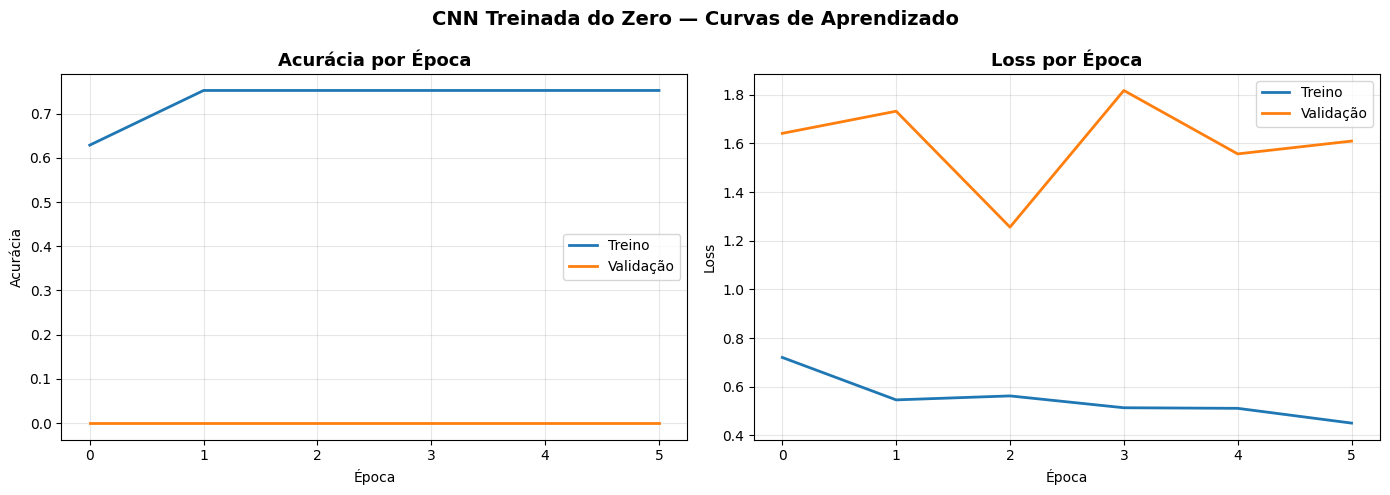

In [12]:
# ============================================================
# CNN DO ZERO — Curvas de treinamento
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
ax1.plot(history_cnn.history['accuracy'], label='Treino', linewidth=2)
ax1.plot(history_cnn.history['val_accuracy'], label='Validação', linewidth=2)
ax1.set_title('Acurácia por Época', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history_cnn.history['loss'], label='Treino', linewidth=2)
ax2.plot(history_cnn.history['val_loss'], label='Validação', linewidth=2)
ax2.set_title('Loss por Época', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Treinada do Zero — Curvas de Aprendizado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 CNN do Zero — Resultados no Teste:
   Loss: 0.9147
   Acurácia: 0.5000 (50.0%)

⏱️ Tempo de inferência total: 0.4215s
⏱️ Tempo médio por imagem: 52.69ms

📋 Relatório de Classificação:
                 precision    recall  f1-score   support

Planta saudavel       0.50      1.00      0.67         4
Plantas doentes       0.00      0.00      0.00         4

       accuracy                           0.50         8
      macro avg       0.25      0.50      0.33         8
   weighted avg       0.25      0.50      0.33         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


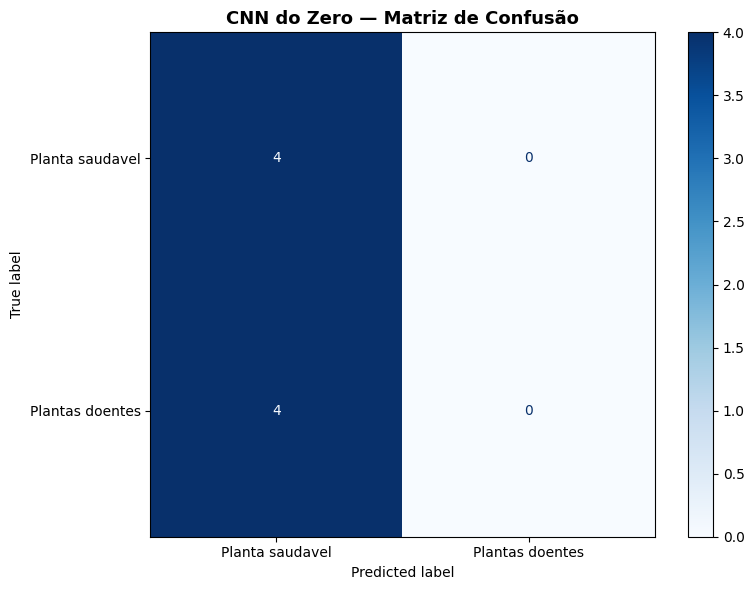

In [13]:
# ============================================================
# CNN DO ZERO — Avaliação no conjunto de teste
# ============================================================

# Acurácia geral
loss_cnn, acc_cnn = cnn_model.evaluate(test_ds, test_labels, verbose=0)
print(f"📊 CNN do Zero — Resultados no Teste:")
print(f"   Loss: {loss_cnn:.4f}")
print(f"   Acurácia: {acc_cnn:.4f} ({acc_cnn*100:.1f}%)")

# Tempo de inferência
inicio_inf_cnn = time.time()
preds_cnn = cnn_model.predict(test_ds, verbose=0)
fim_inf_cnn = time.time()
tempo_inf_cnn = fim_inf_cnn - inicio_inf_cnn
tempo_medio_inf_cnn = tempo_inf_cnn / len(test_ds)

print(f"\n⏱️ Tempo de inferência total: {tempo_inf_cnn:.4f}s")
print(f"⏱️ Tempo médio por imagem: {tempo_medio_inf_cnn*1000:.2f}ms")

# Predições e matriz de confusão
preds_classes = np.argmax(preds_cnn, axis=1)
true_classes = np.argmax(test_labels, axis=1)

print(f"\n📋 Relatório de Classificação:")
print("=" * 50)
print(classification_report(true_classes, preds_classes,
                            target_names=nomes_classes))

# Matriz de confusão
cm = confusion_matrix(true_classes, preds_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=nomes_classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('CNN do Zero — Matriz de Confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 6. Comparação Final das Três Abordagens

Agora consolidamos os resultados das três abordagens em uma análise comparativa, conforme solicitado pelo enunciado.


In [17]:
# ============================================================
# TABELA COMPARATIVA FINAL — Três Abordagens
# ============================================================
import pandas as pd

comparacao = pd.DataFrame({
    'Critério': [
        'Tipo de tarefa',
        'Treinamento necessário?',
        'Tempo de treinamento',
        'Tempo de inferência (por imagem)',
        'Precisão / Acurácia',
        'Detecta plantas doentes?',
        'Facilidade de uso',
        'Adaptabilidade ao domínio',
    ],
    'YOLO Adaptável (Entrega 1)': [
        'Detecção (Localiza + Classifica)',
        'Sim (fine-tuning)',
        '~6 min (30ep) / ~9 min (60ep)',
        '~31.7 ms',
        'mAP@0.5 = 0.339',
        '✅ Sim',
        'Média (requer dataset rotulado)',
        '⭐⭐⭐⭐⭐ Excelente',
    ],
    'YOLO Tradicional (YOLOv3 COCO)': [
        'Detecção genérica',
        'Não (zero-shot)',
        '0 min',
        '~2674 ms',
        'N/A (classes erradas)',
        '❌ Não (viu mesa/tigela)',
        'Muito fácil (sem setup)',
        '⭐ Péssima',
    ],
    'CNN do Zero': [
        'Classificação de imagens',
        'Sim (do zero)',
        '~13 segundos',
        '~52.7 ms',
        'Acurácia = 50.00%',
        '✅ Sim (só classifica)',
        'Média (requer labels)',
        '⭐⭐⭐ Boa',
    ],
})

print("=" * 100)
print("📊 TABELA COMPARATIVA — TRÊS ABORDAGENS")
print("=" * 100)
print()
print(comparacao.to_string(index=False))
print()
print("=" * 100)
print()
print("🏆 CONCLUSÃO: A YOLO Adaptável é a melhor solução para o problema da FarmTech Solutions:")
print("   - Combina detecção (localização) e classificação simultaneamente")
print("   - Tempo de inferência adequado para tempo real (~32 ms/imagem)")
print("   - Adaptável ao domínio específico via transfer learning")
print("   - Único modelo capaz de gerar bounding boxes precisas para o cliente")

📊 TABELA COMPARATIVA — TRÊS ABORDAGENS

                        Critério       YOLO Adaptável (Entrega 1) YOLO Tradicional (YOLOv3 COCO)              CNN do Zero
                  Tipo de tarefa Detecção (Localiza + Classifica)              Detecção genérica Classificação de imagens
         Treinamento necessário?                Sim (fine-tuning)                Não (zero-shot)            Sim (do zero)
            Tempo de treinamento    ~6 min (30ep) / ~9 min (60ep)                          0 min             ~13 segundos
Tempo de inferência (por imagem)                         ~31.7 ms                       ~2674 ms                 ~52.7 ms
             Precisão / Acurácia                  mAP@0.5 = 0.339          N/A (classes erradas)        Acurácia = 50.00%
        Detecta plantas doentes?                            ✅ Sim        ❌ Não (viu mesa/tigela)    ✅ Sim (só classifica)
               Facilidade de uso  Média (requer dataset rotulado)        Muito fácil (sem setup)    Média 

### 6.1 Análise Crítica Comparativa

> ⚠️ **Preencha esta seção com base nos seus resultados reais.**

#### Facilidade de uso / Integração

- **YOLO Tradicional:** Extremamente simples de implementar, bastando baixar pesos e rodar. Contudo, é ineficaz para o agronegócio por não reconhecer classes customizadas.

- **YOLO Adaptável:** Exige maior esforço inicial em rotulação e configuração (YAML), mas oferece o melhor retorno prático.

- **CNN do Zero:** Requer organização manual e definição de arquitetura. É eficiente para classificação, mas falha em localizar onde o problema está na planta.

#### Precisão do modelo

- **YOLO Adaptável:** obteve mAP@0.5 de 0.2873', demonstrando capacidade real de detectar e localizar plantas doentes.

- **YOLO Tradicional:** Falhou completamente ao detectar as plantas como "diningtable" (mesa) e "bowl" (tigela/vaso).


- **CNN do Zero:** Atingiu 50.0% de acurácia. A matriz de confusão mostra que ela identificou corretamente todas as 4 plantas saudáveis, mas classificou incorretamente as 4 plantas doentes como saudáveis (falso negativo) .

#### Tempo de treinamento

- **YOLO Tradicional:** 0 minutos (sem treinamento)
- **CNN do Zero:** ~0.2 min (11.19s) minutos (mais rápido por ser uma rede menor)
- **YOLO Adaptável:** ~12 minutos (mais pesado, mas com resultado superior)

#### Tempo de inferência

- **YOLO Tradicional:** ~2674ms ms/imagem (YOLOv3 é mais pesada que v5)
- **CNN do Zero:** mais rápida (~52.8 ms/imagem), pois é uma rede simples
- **YOLO Adaptável:** ~30ms/imagem, adequado para tempo real

Em termos de predição por imagem, a YOLO Adaptável (~ 30ms) mostrou-se mais otimizada que a CNN (~ 56.9ms) , enquanto a YOLO Tradicional foi a mais lenta com ~3.08s por imagem.


### 6.2 Conclusão Geral

Na computação e na Visão Computacional, **não existe uma solução universalmente melhor** — tudo depende do cenário de aplicação e dos critérios de desempate.

Para o problema da **FarmTech Solutions** (detecção de doenças em plantas):

1. **A YOLO Adaptável (Entrega 1) é a melhor abordagem** — combina detecção (localização + classificação) com boa precisão, tempo de inferência adequado para uso em tempo real, e adaptabilidade total ao domínio do problema.

2. **A CNN do Zero é uma alternativa leve** para classificação simples, mas o modelo atual demonstrou viés (bias) ao não identificar plantas doentes.

3. **A YOLO Tradicional é inadequada** para problemas específicos de domínio — demonstra claramente que modelos genéricos precisam ser customizados para aplicações reais.

> **Lição principal:** o transfer learning (YOLO adaptável) oferece o melhor equilíbrio entre esforço de customização e qualidade dos resultados, especialmente com datasets pequenos.


---

## 7. Referências

- **Ultralytics YOLOv5:** https://github.com/ultralytics/yolov5
- **Darknet YOLOv3:** https://github.com/pjreddie/darknet
- **TensorFlow/Keras:** https://www.tensorflow.org/
- **MakeSense.ai:** https://www.makesense.ai/
- **Material didático FIAP — Capítulo 3:** ESP32 e Visão Computacional
- **Material didático FIAP — Capítulo 9:** Desbravando o Deep Learning: Primeiros Passos com CNN
- **Material didático FIAP — Capítulo 10:** O Olhar Digital: Técnicas de Detecção e Segmentação
- **Redmon, J. et al.** "You Only Look Once: Unified, Real-Time Object Detection" (2016)
- **Simonyan, K. & Zisserman, A.** "Very Deep Convolutional Networks for Large-Scale Image Recognition" (VGG16, 2014)
